# Codveda Technologies — Data Analytics Internship
## Level 2: Intermediate Data Analysis

---

| Detail | Information |
|---|---|
| **Intern Name** | Omokhoa Oshose Tosayoname |
| **Intern ID** | CV/A1/61250 |
| **Position** | Data Analysis Intern |
| **Organisation** | Codveda Technologies |
| **Level** | 2 — Intermediate |
| **Tasks Completed** | Task 2: Time Series Analysis · Task 3: Clustering Analysis (K-Means) |
| **Datasets** | Stock Prices Data Set (Stock_Prices_Data_Set.csv) · Iris Dataset (iris.csv) |
| **Tools** | Python, pandas, matplotlib, seaborn, statsmodels, scikit-learn |
| **Date** | March 2026 |

---

## Overview

This notebook presents the completed work for **Level 2 (Intermediate)** of the Codveda Technologies Data Analytics Internship. Two tasks are covered:

- **Task 2 — Time Series Analysis:** Analysing Apple Inc. (AAPL) stock price data from 2014–2017 to detect trends, seasonality, and residual patterns using decomposition and moving average smoothing.
- **Task 3 — Clustering Analysis (K-Means):** Applying unsupervised machine learning to the Iris dataset to discover natural groupings in the data without using species labels, then validating the discovered clusters against the true species.

These tasks represent a step up from Level 1 — moving from description to discovery.

---

## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Task 2 — Time Series Analysis](#2-task-2--time-series-analysis)
   - [2.1 Dataset Loading and Exploration](#21-dataset-loading-and-exploration)
   - [2.2 Data Preparation](#22-data-preparation)
   - [2.3 Raw Time Series Plot](#23-raw-time-series-plot)
   - [2.4 Moving Average Smoothing](#24-moving-average-smoothing)
   - [2.5 Time Series Decomposition](#25-time-series-decomposition)
   - [2.6 Multi-Stock Comparison](#26-multi-stock-comparison)
3. [Task 3 — Clustering Analysis (K-Means)](#3-task-3--clustering-analysis-k-means)
   - [3.1 Dataset Loading and Preparation](#31-dataset-loading-and-preparation)
   - [3.2 Feature Standardisation](#32-feature-standardisation)
   - [3.3 Elbow Method — Finding Optimal K](#33-elbow-method--finding-optimal-k)
   - [3.4 Fitting K-Means with K=3](#34-fitting-k-means-with-k3)
   - [3.5 Cluster Visualisation](#35-cluster-visualisation)
4. [Key Findings and Conclusions](#4-key-findings-and-conclusions)


---
## 1. Environment Setup

This notebook requires several libraries beyond the basics used in Level 1:

- **statsmodels** — provides the `seasonal_decompose` function for time series decomposition
- **scikit-learn** — provides `StandardScaler` for feature normalisation and `KMeans` for clustering
- **sklearn.decomposition.PCA** — used to project 4-dimensional cluster data into 2D for visualisation


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

os.makedirs('outputs', exist_ok=True)

print("✓ All libraries imported successfully.")
print(f"  pandas        version: {pd.__version__}")
print(f"  numpy         version: {np.__version__}")
print(f"  matplotlib    version: {matplotlib.__version__}")
print(f"  seaborn       version: {sns.__version__}")
import sklearn
print(f"  scikit-learn  version: {sklearn.__version__}")
import statsmodels
print(f"  statsmodels   version: {statsmodels.__version__}")


✓ All libraries imported successfully.
  pandas        version: 2.2.2
  numpy         version: 2.0.2
  matplotlib    version: 3.10.0
  seaborn       version: 0.13.2
  scikit-learn  version: 1.6.1
  statsmodels   version: 0.14.6


---
## 2. Task 2 — Time Series Analysis

**Task Description:** Analyse a time-series dataset to detect trends and seasonality.

**Objectives:**
- Plot time-series data and identify patterns
- Decompose the series into trend, seasonality, and residuals using statsmodels
- Perform moving average smoothing and plot the results

### What is a Time Series?

A **time series** is any dataset where observations are recorded sequentially over time. Stock prices are a classic example — every trading day produces a new closing price, and those prices string together into a story of market behaviour.

Time series analysis asks three fundamental questions:
1. **What is the overall direction (trend)?** Is the stock generally going up or down?
2. **Are there repeating patterns (seasonality)?** Does the stock follow a predictable annual cycle?
3. **What is pure noise (residuals)?** After removing trend and seasonality, what random variation remains?

We focus on **Apple Inc. (AAPL)** — one of the world's most well-known stocks, covering the period January 2014 to December 2017.


### 2.1 Dataset Loading and Exploration


In [17]:
# Load the full stock prices dataset
df_stocks = pd.read_csv('datasets/Stock_Prices_Data_Set.csv')

print("=" * 55)
print("STOCK PRICES DATASET OVERVIEW")
print("=" * 55)
print(f"Shape          : {df_stocks.shape[0]:,} rows × {df_stocks.shape[1]} columns")
print(f"Columns        : {df_stocks.columns.tolist()}")
print(f"Unique symbols : {df_stocks['symbol'].nunique()}")
print(f"Date range     : {df_stocks['date'].min()} to {df_stocks['date'].max()}")
print(f"Missing values :\n{df_stocks.isnull().sum()}")
print()
print("SAMPLE (first 3 rows):")
df_stocks.head(3)


STOCK PRICES DATASET OVERVIEW
Shape          : 497,472 rows × 7 columns
Columns        : ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume']
Unique symbols : 505
Date range     : 2014-01-02 to 2017-12-29
Missing values :
symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

SAMPLE (first 3 rows):


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711


**Dataset observations:**

The dataset contains **497,472 rows** representing daily trading data for **505 stock symbols** spanning 4 years (2014–2017). Each row records a single stock's trading activity for one day: opening price, daily high, daily low, closing price, and trading volume.

We use the **closing price** (`close`) as our primary variable. The closing price is the industry standard reference for time series analysis because it represents the final agreed-upon price of each trading day — the market's last word on a stock's value before the next session opens.

There are a small number of missing values in `open`, `high`, and `low` columns, but `close` is complete — no imputation required.


### 2.2 Data Preparation

Two key preparation steps are required before plotting:

1. **Filter for AAPL** — isolate Apple's records from the 505 symbols
2. **Convert date column** — the `date` column is stored as a string; we must convert it to a proper `datetime` type so Python understands the temporal ordering. This is essential for time series operations.
3. **Set date as index** — time series operations in pandas work best when the datetime column is the index


In [18]:
# Filter for Apple Inc.
aapl = df_stocks[df_stocks['symbol'] == 'AAPL'].copy()

# Convert date string to datetime and sort chronologically
aapl['date'] = pd.to_datetime(aapl['date'])
aapl = aapl.sort_values('date')
aapl.set_index('date', inplace=True)

# Extract closing price series
close = aapl['close']

print("AAPL TIME SERIES READY")
print("=" * 45)
print(f"Date range     : {close.index.min().date()} to {close.index.max().date()}")
print(f"Trading days   : {len(close):,}")
print(f"Missing values : {close.isnull().sum()}")
print()
print("PRICE SUMMARY:")
print(f"  Opening price : ${close.iloc[0]:.2f}")
print(f"  Closing price : ${close.iloc[-1]:.2f}")
print(f"  Minimum price : ${close.min():.2f}")
print(f"  Maximum price : ${close.max():.2f}")
print(f"  Mean price    : ${close.mean():.2f}")
print(f"  Total return  : ${close.iloc[-1] - close.iloc[0]:.2f} "
      f"({((close.iloc[-1]/close.iloc[0])-1)*100:.1f}%)")


AAPL TIME SERIES READY
Date range     : 2014-01-02 to 2017-12-29
Trading days   : 1,007
Missing values : 0

PRICE SUMMARY:
  Opening price : $79.02
  Closing price : $169.23
  Minimum price : $71.40
  Maximum price : $176.42
  Mean price    : $116.84
  Total return  : $90.21 (114.2%)


Apple's stock grew from **$79.02 to $169.23** over this 4-year period — a **114.2% total return**. This context makes the time series story compelling before we've even plotted anything. The question is: was that growth steady and linear, or did it follow more complex patterns with dips, recoveries, and seasonal cycles?


### 2.3 Raw Time Series Plot

The first step in any time series analysis is always to **plot the raw data**. This gives us an immediate visual sense of direction, volatility, and any obvious anomalies before applying any mathematical transformations.


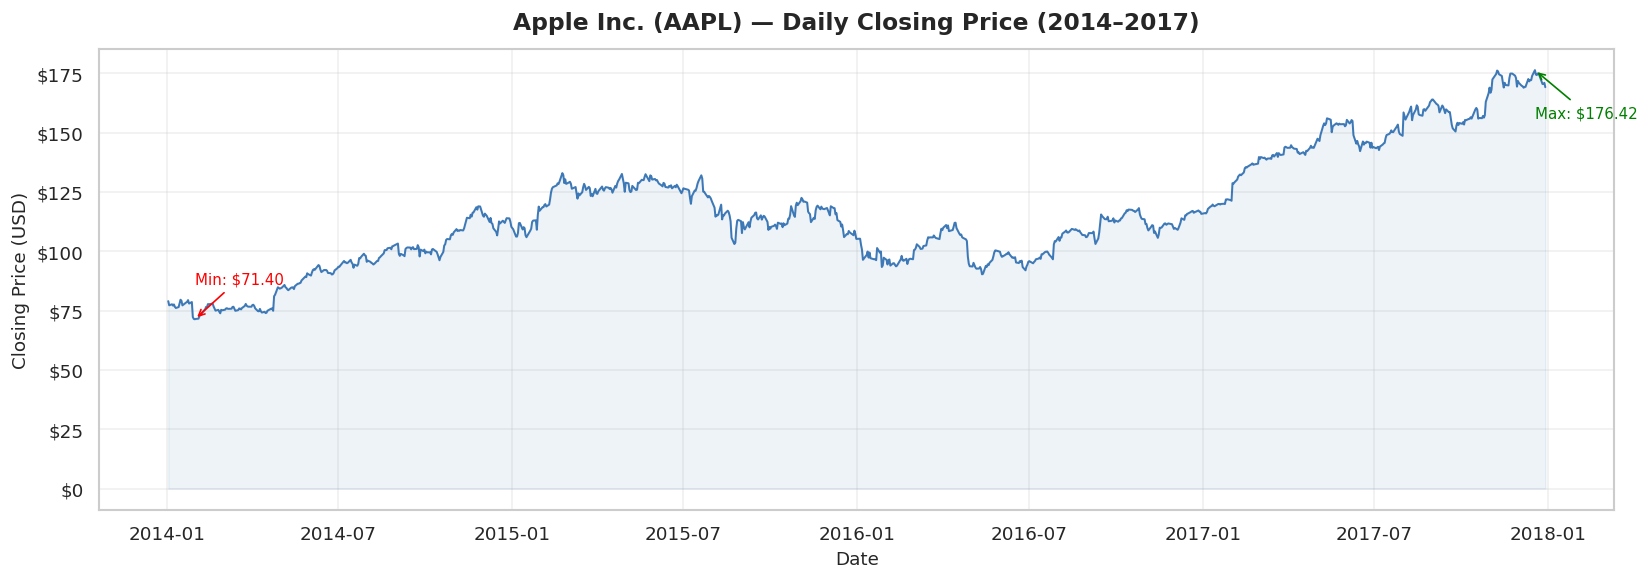

✓ Raw time series saved to outputs/07_aapl_raw_timeseries.png


In [19]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(close.index, close.values, color='#2B6CB0', linewidth=1.2, alpha=0.9)
ax.fill_between(close.index, close.values, alpha=0.08, color='#2B6CB0')

ax.set_title('Apple Inc. (AAPL) — Daily Closing Price (2014–2017)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Closing Price (USD)', fontsize=11)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))

# Annotate min and max points
ax.annotate(f'Min: ${close.min():.2f}',
            xy=(close.idxmin(), close.min()),
            xytext=(close.idxmin(), close.min() + 15),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=9, color='red')
ax.annotate(f'Max: ${close.max():.2f}',
            xy=(close.idxmax(), close.max()),
            xytext=(close.idxmax(), close.max() - 20),
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=9, color='green')

plt.tight_layout()
plt.savefig('outputs/07_aapl_raw_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Raw time series saved to outputs/07_aapl_raw_timeseries.png")


**Insight:** The raw plot reveals a clear overall upward trend from 2014 to 2017, but the path is far from straight. There is a notable dip in mid-2015 to mid-2016 (reaching the minimum of $71.40) before a strong recovery and continued climb to the maximum of $176.42. The day-to-day jaggedness is market noise — in the next section we smooth it out to see the underlying trend more clearly.


### 2.4 Moving Average Smoothing

A **moving average** replaces each data point with the average of a surrounding window of observations. This smooths out short-term fluctuations (noise) and makes the underlying trend visible.

We compute two moving averages:
- **30-day MA** — captures short-term momentum (roughly one trading month)
- **90-day MA** — captures medium-term trend (roughly one quarter)

When the 30-day MA crosses **above** the 90-day MA, it signals upward momentum (bullish signal). When it crosses **below**, it signals downward momentum (bearish signal). In trading, these are known as the **Golden Cross** and **Death Cross** respectively.

> **Formula:** Moving Average at time *t* with window *w* = (1/w) × Σ(x_{t-w+1} to x_t)


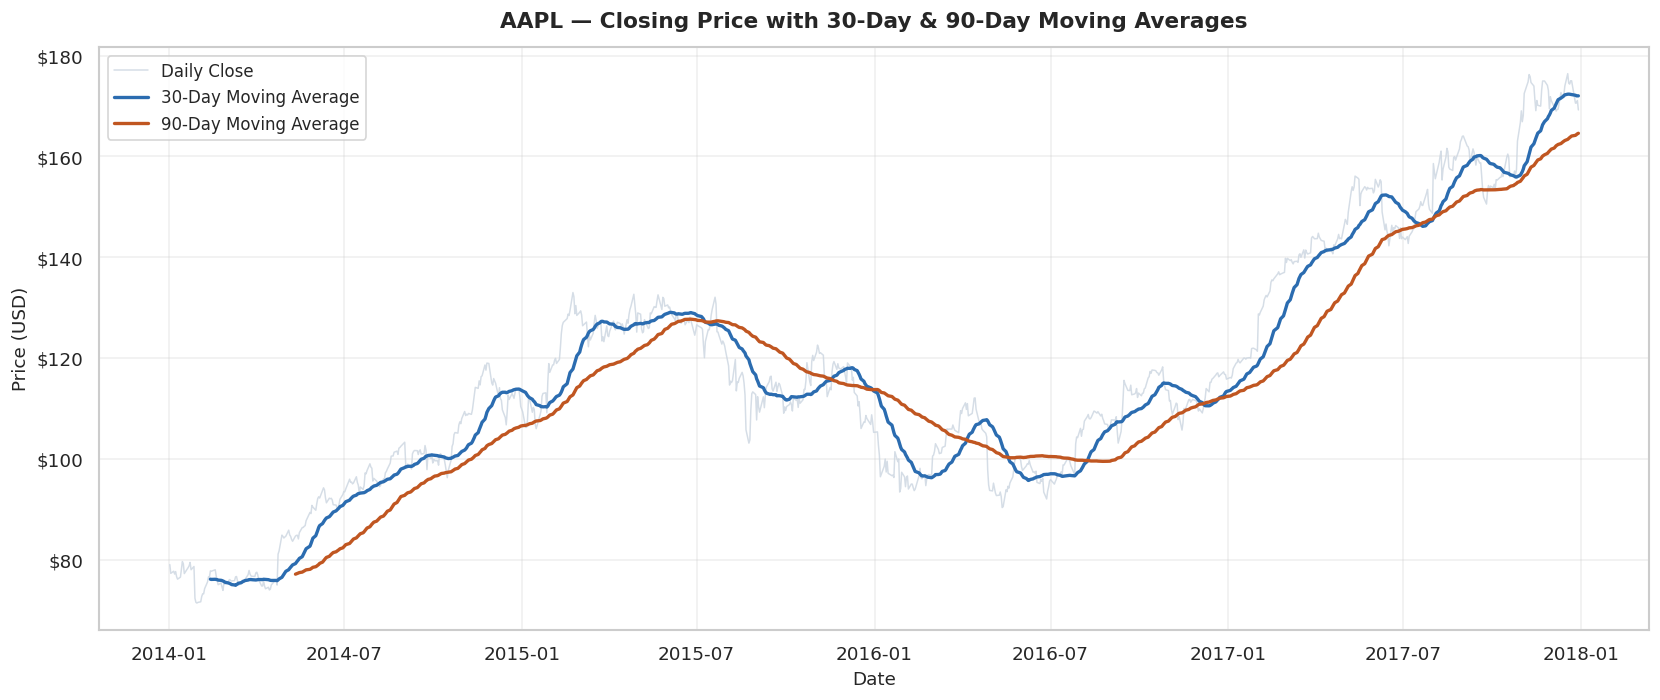

✓ Moving averages saved to outputs/08_moving_averages.png


In [20]:
# Compute moving averages
ma30 = close.rolling(window=30).mean()
ma90 = close.rolling(window=90).mean()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(close.index, close.values,
        color='#CBD5E0', linewidth=0.9, alpha=0.8, label='Daily Close')
ax.plot(ma30.index, ma30.values,
        color='#2B6CB0', linewidth=2.0, label='30-Day Moving Average')
ax.plot(ma90.index, ma90.values,
        color='#C05621', linewidth=2.0, label='90-Day Moving Average')

ax.set_title('AAPL — Closing Price with 30-Day & 90-Day Moving Averages',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Price (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/08_moving_averages.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Moving averages saved to outputs/08_moving_averages.png")


**Insight:** With the daily noise removed, the trend becomes much cleaner. The 30-day (blue) and 90-day (orange) lines diverge and converge throughout the period. Notice the mid-2015 period where the 30-day line dips sharply below the 90-day line — a bearish signal that preceded the stock's decline to its minimum. From 2016 onwards, the 30-day line stays consistently above the 90-day line, indicating sustained bullish momentum through to the end of 2017.


### 2.5 Time Series Decomposition

Decomposition formally separates a time series into its three structural components:

| Component | Description |
|---|---|
| **Trend** | The long-term direction of the series |
| **Seasonality** | Regular, repeating patterns on a fixed cycle |
| **Residuals** | What remains after trend and seasonality are removed — pure noise |

We use the **multiplicative model** because stock prices are proportional — a 10% swing at $80 looks different in absolute dollar terms than a 10% swing at $160. In a multiplicative model, the components **multiply** together: `Observed = Trend × Seasonal × Residual`.

The `period=252` parameter represents approximately one trading year (252 trading days), telling the model to look for annual seasonal cycles.


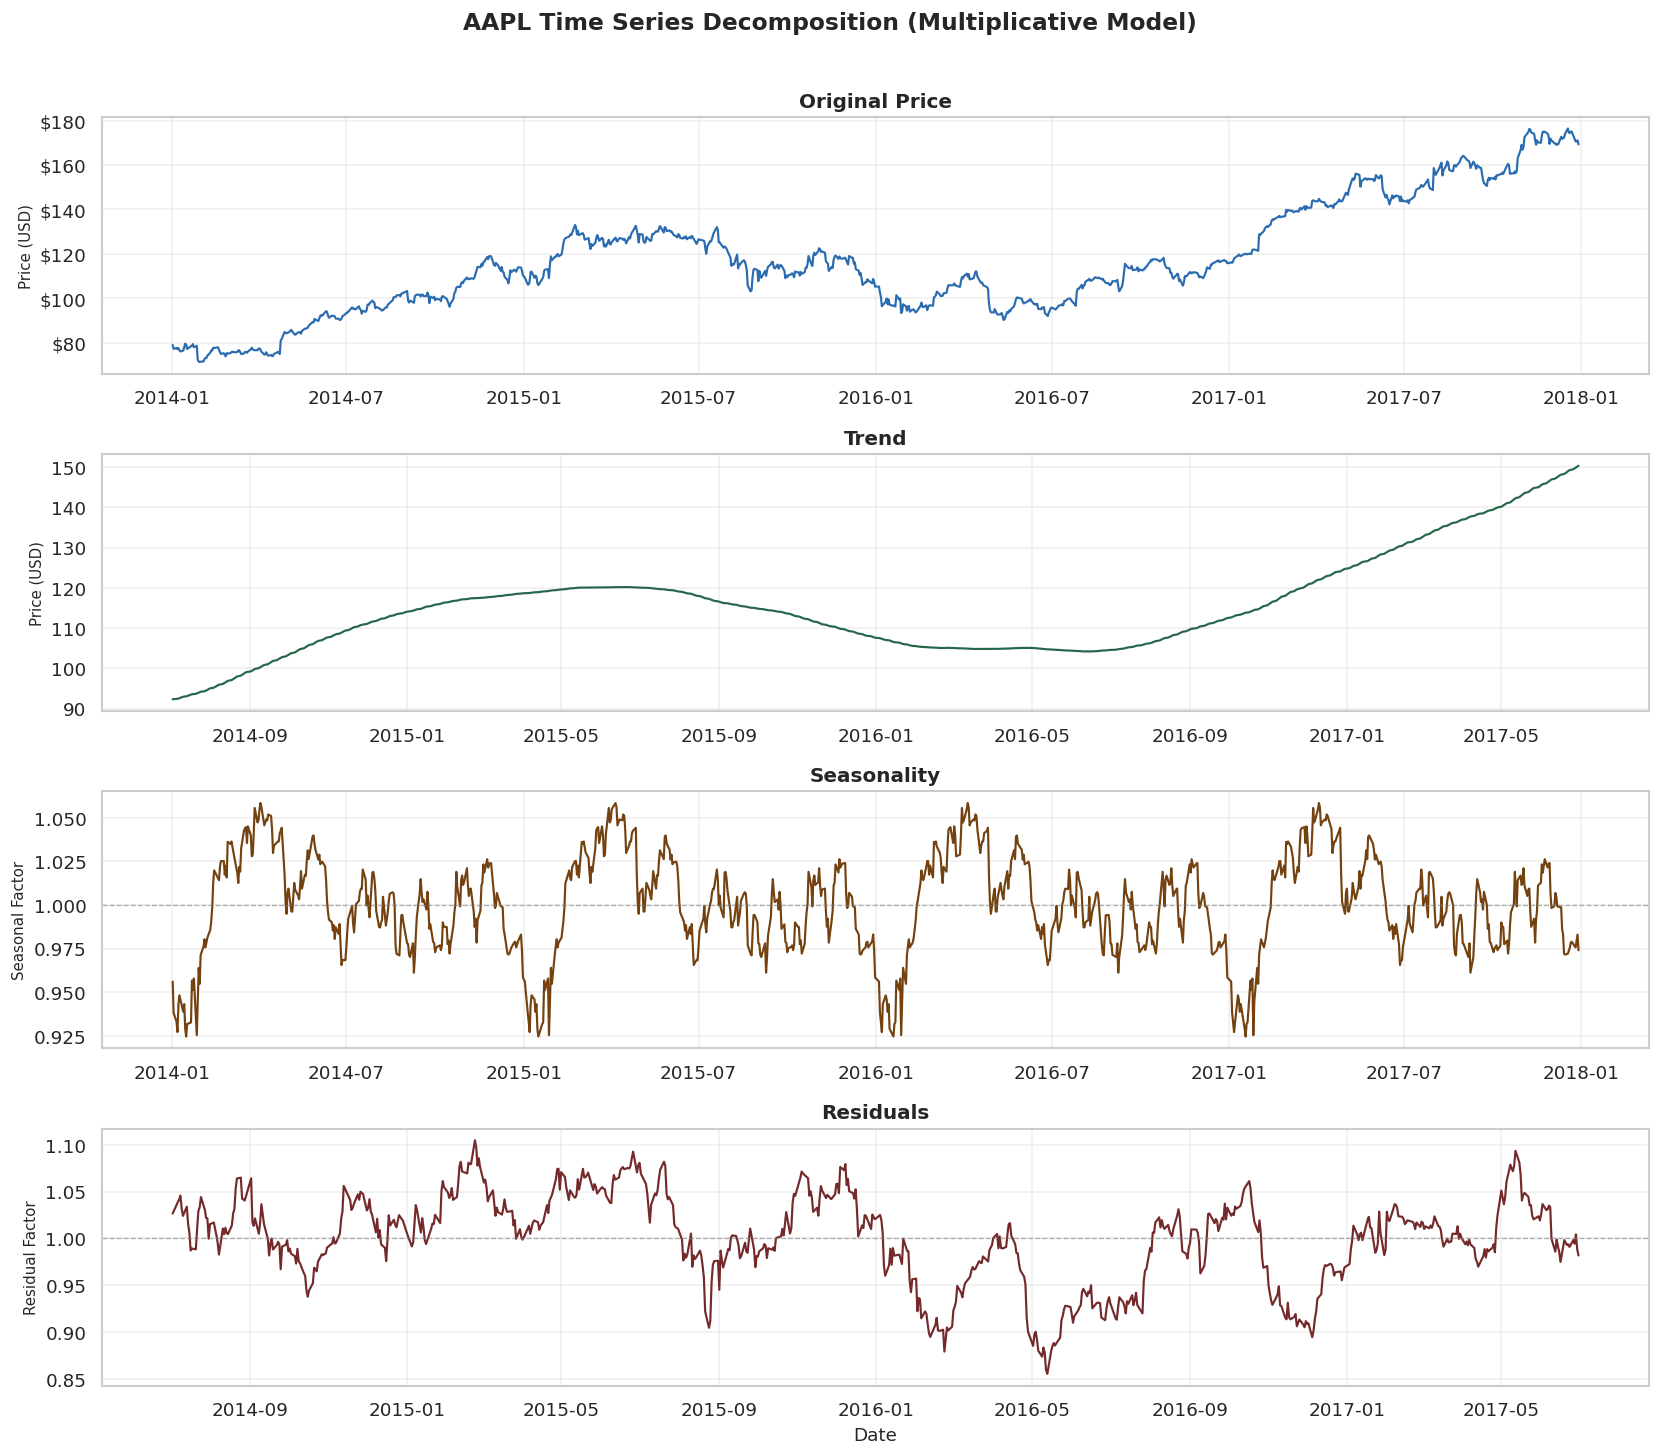

✓ Decomposition saved to outputs/09_decomposition.png


In [21]:
# Decompose the AAPL time series
decomposition = seasonal_decompose(close, model='multiplicative', period=252)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('AAPL Time Series Decomposition (Multiplicative Model)',
             fontsize=14, fontweight='bold', y=1.01)

components = [
    (close,                   'Original Price',  '#2B6CB0'),
    (decomposition.trend,     'Trend',           '#276749'),
    (decomposition.seasonal,  'Seasonality',     '#744210'),
    (decomposition.resid,     'Residuals',       '#742A2A'),
]
ylabels = ['Price (USD)', 'Price (USD)', 'Seasonal Factor', 'Residual Factor']

for ax, (data, title, color), ylabel in zip(axes, components, ylabels):
    ax.plot(data.index, data.values, color=color, linewidth=1.3)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(alpha=0.3)
    if title == 'Original Price':
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
    if title in ['Seasonality', 'Residuals']:
        ax.axhline(y=1, color='gray', linestyle='--',
                   linewidth=0.8, alpha=0.6)

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/09_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Decomposition saved to outputs/09_decomposition.png")


**Interpretation of decomposition components:**

- **Trend panel:** Shows a smooth, clean upward curve interrupted by a dip in 2015–2016, then a strong recovery. This is the "true" direction of the stock stripped of all cyclical and random effects.

- **Seasonality panel:** Reveals a repeating annual wave — Apple's stock tends to follow a predictable within-year pattern. Values above 1.0 indicate periods where the stock trades above its trend, values below 1.0 indicate periods below. This likely reflects seasonal patterns in consumer electronics sales (strong Q4 from holiday iPhone purchases) and earnings announcement cycles.

- **Residuals panel:** The residual values cluster tightly around 1.0 for most of the period, meaning the model explains the variation well. Sharp spikes in the residuals represent sudden, unpredictable price movements — typically caused by unexpected news, earnings surprises, or macroeconomic events.


### 2.6 Multi-Stock Comparison

To contextualise Apple's performance, we compare it against three other major technology companies: **Microsoft (MSFT)**, **Alphabet/Google (GOOGL)**, and **Amazon (AMZN)**.

The bottom chart normalises all stocks to a base of 100 at the start of the period. This removes the distortion of absolute price differences (Amazon traded at ~$400 while Apple was at ~$79) and allows fair comparison of **percentage growth** over the same period.


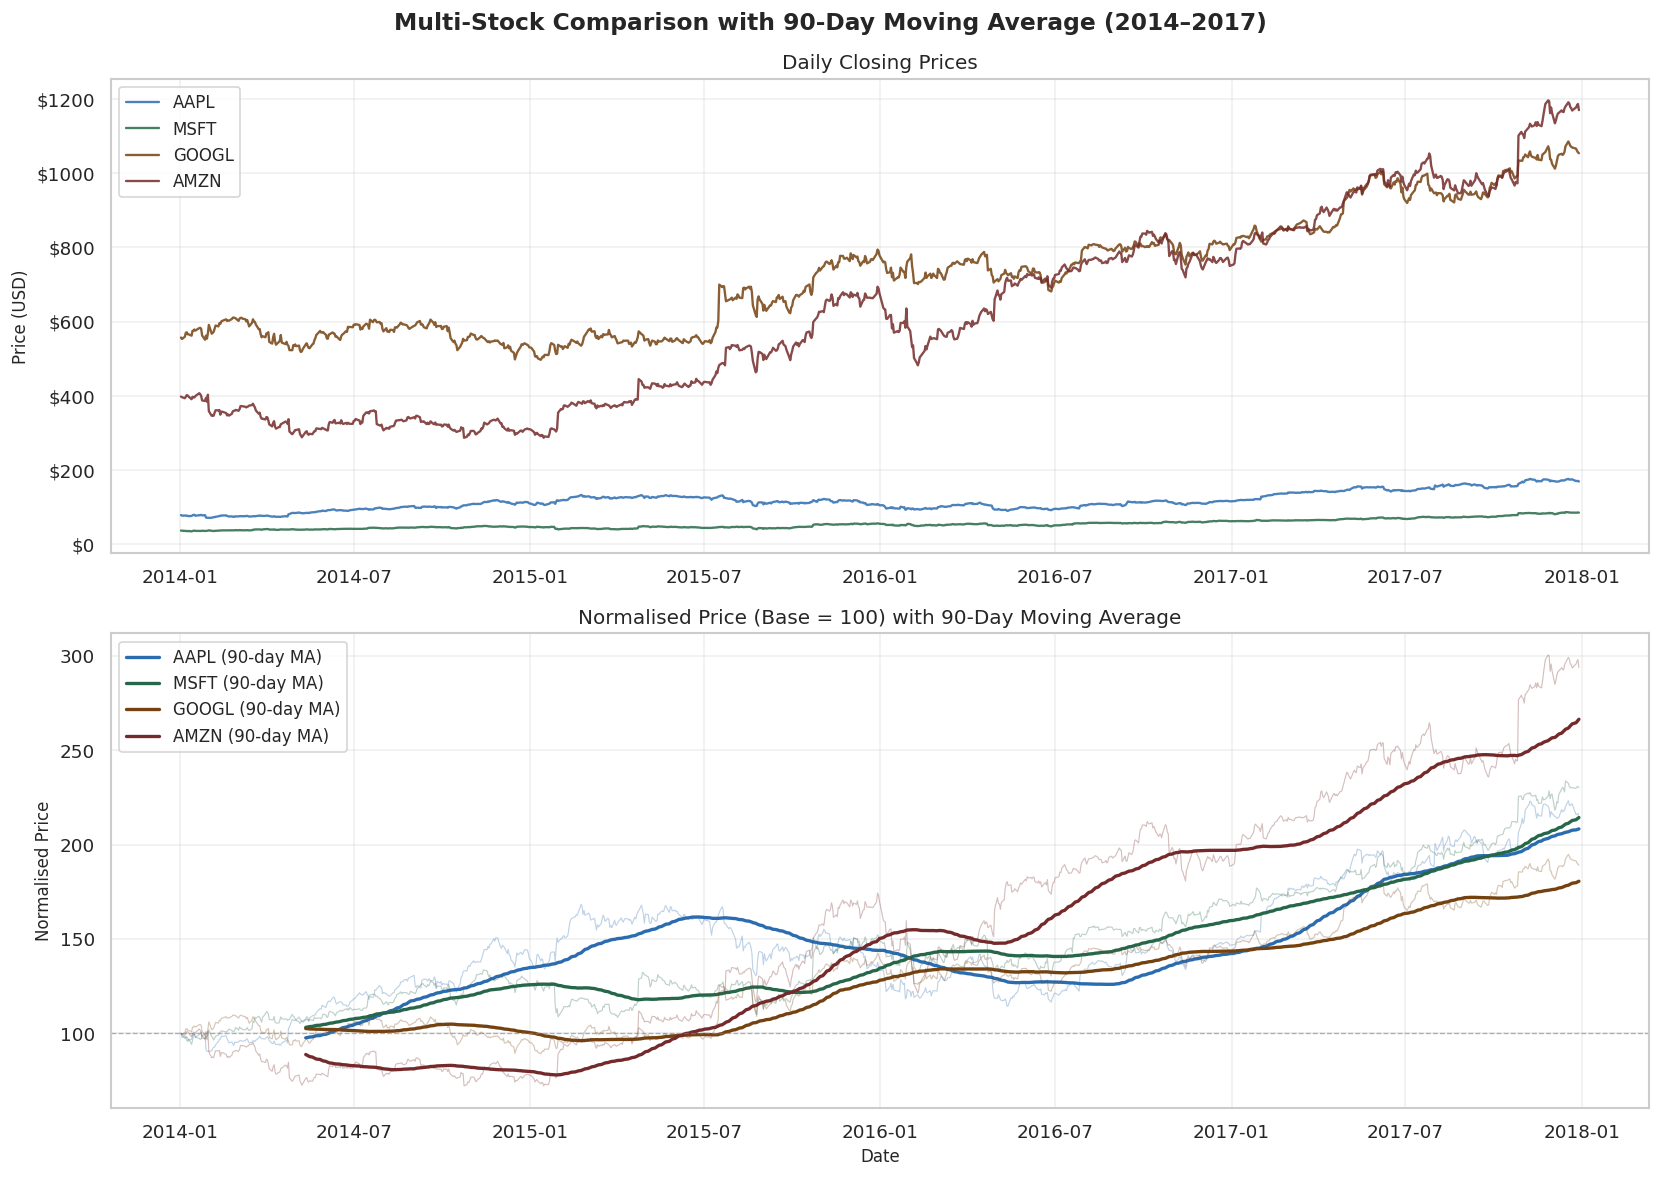

✓ Multi-stock comparison saved to outputs/10_multi_stock_comparison.png


In [22]:
symbols = ['AAPL', 'MSFT', 'GOOGL', 'AMZN']
sym_colors = ['#2B6CB0', '#276749', '#744210', '#742A2A']

df_stocks['date'] = pd.to_datetime(df_stocks['date'])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Multi-Stock Comparison with 90-Day Moving Average (2014–2017)',
             fontsize=14, fontweight='bold')

# Top: raw closing prices
for sym, col in zip(symbols, sym_colors):
    data = df_stocks[df_stocks['symbol'] == sym].sort_values('date')
    axes[0].plot(data['date'], data['close'],
                 label=sym, color=col, linewidth=1.4, alpha=0.85)
axes[0].set_title('Daily Closing Prices', fontsize=12)
axes[0].set_ylabel('Price (USD)', fontsize=10)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:.0f}'))

# Bottom: normalised to 100 at start
for sym, col in zip(symbols, sym_colors):
    data = (df_stocks[df_stocks['symbol'] == sym]
            .sort_values('date')
            .set_index('date'))
    normalised = (data['close'] / data['close'].iloc[0]) * 100
    ma90 = normalised.rolling(90).mean()
    axes[1].plot(normalised.index, normalised.values,
                 color=col, linewidth=0.7, alpha=0.3)
    axes[1].plot(ma90.index, ma90.values,
                 color=col, linewidth=2.0,
                 label=f'{sym} (90-day MA)')

axes[1].set_title('Normalised Price (Base = 100) with 90-Day Moving Average',
                  fontsize=12)
axes[1].set_ylabel('Normalised Price', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].legend(fontsize=10)
axes[1].axhline(100, color='gray', linestyle='--',
                linewidth=0.8, alpha=0.6)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/10_multi_stock_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Multi-stock comparison saved to outputs/10_multi_stock_comparison.png")


**Insight:** The normalised chart tells a striking story. Amazon (dark red) dramatically outperformed all peers, growing to nearly **4× its starting value** by end of 2017. Apple, Microsoft, and Google all delivered solid but more modest growth of roughly 100–150%. The 2015–2016 dip visible in Apple's individual chart also appears in Microsoft and Google, suggesting a broader technology sector correction during that period rather than an Apple-specific issue.


---
## 3. Task 3 — Clustering Analysis (K-Means)

**Task Description:** Implement K-Means clustering to group similar data points together based on feature similarities.

**Objectives:**
- Standardise the dataset using StandardScaler
- Apply K-Means clustering and determine the optimal number of clusters using the elbow method
- Visualise clusters using 2D scatter plots

### What is K-Means Clustering?

K-Means is an **unsupervised machine learning algorithm** — meaning it finds patterns in data without being told what those patterns are. Unlike the EDA in Level 1 where we used the known `species` labels, here we deliberately ignore those labels and ask: *"Can an algorithm discover the three species on its own?"*

**How K-Means works:**
1. Randomly place K centroid points in the feature space
2. Assign every data point to the nearest centroid (creating K clusters)
3. Move each centroid to the average position of its assigned points
4. Repeat steps 2–3 until assignments no longer change

The algorithm minimises **inertia** — the total sum of squared distances from each point to its cluster centre. Lower inertia = tighter, more compact clusters.

**Dataset:** We reuse the Iris dataset from Level 1, this time treating it as if the species labels do not exist.


### 3.1 Dataset Loading and Preparation


In [23]:
# Load the Iris dataset
df_iris = pd.read_csv('datasets/iris.csv')
df_iris = df_iris.drop_duplicates().reset_index(drop=True)

numerical = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Separate features from labels
# We store true_labels separately to validate results AFTER clustering
X = df_iris[numerical]
true_labels = df_iris['species']

print("IRIS DATASET READY FOR CLUSTERING")
print("=" * 45)
print(f"Records  : {len(df_iris)}")
print(f"Features : {numerical}")
print(f"(Species labels hidden from algorithm)")
print()
print("FEATURE RANGES (before standardisation):")
for col in numerical:
    print(f"  {col}: {X[col].min():.2f} — {X[col].max():.2f}")


IRIS DATASET READY FOR CLUSTERING
Records  : 147
Features : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
(Species labels hidden from algorithm)

FEATURE RANGES (before standardisation):
  sepal_length: 4.30 — 7.90
  sepal_width: 2.00 — 4.40
  petal_length: 1.00 — 6.90
  petal_width: 0.10 — 2.50


### 3.2 Feature Standardisation

Before applying K-Means, we must **standardise** the features. K-Means uses Euclidean distance to assign points to clusters — if one feature has much larger numerical values than another, it will dominate the distance calculation simply because of its scale, not because it is more important.

`StandardScaler` transforms each feature to have:
- **Mean = 0** — centres the data around zero
- **Standard Deviation = 1** — scales all features to the same unit of spread

The formula applied to each value x is: **z = (x − μ) / σ**

where μ is the feature mean and σ is the standard deviation.


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("FEATURE RANGES AFTER STANDARDISATION:")
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical)
for col in X_scaled_df.columns:
    print(f"  {col}: mean = {X_scaled_df[col].mean():.4f}, "
          f"std = {X_scaled_df[col].std():.4f}")

print()
print("✓ All features now have mean ≈ 0 and std ≈ 1.")
print("  K-Means will treat all features equally.")


FEATURE RANGES AFTER STANDARDISATION:
  sepal_length: mean = -0.0000, std = 1.0034
  sepal_width: mean = 0.0000, std = 1.0034
  petal_length: mean = -0.0000, std = 1.0034
  petal_width: mean = -0.0000, std = 1.0034

✓ All features now have mean ≈ 0 and std ≈ 1.
  K-Means will treat all features equally.


### 3.3 Elbow Method — Finding the Optimal Number of Clusters

A critical question in K-Means is: **how many clusters should we use?**

The **Elbow Method** answers this by running K-Means for a range of K values (1 through 10) and plotting the resulting inertia for each. As K increases, inertia always decreases — but at some point the improvement becomes marginal. The point where the curve "bends" like an elbow is the optimal K.

Mathematically, inertia is defined as:

> **Inertia = Σ (distance from each point to its cluster centroid)²**


In [25]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"  K = {k:2d}  |  Inertia: {km.inertia_:.2f}")


  K =  1  |  Inertia: 588.00
  K =  2  |  Inertia: 220.86
  K =  3  |  Inertia: 138.26
  K =  4  |  Inertia: 112.91
  K =  5  |  Inertia: 89.89
  K =  6  |  Inertia: 80.84
  K =  7  |  Inertia: 70.01
  K =  8  |  Inertia: 62.11
  K =  9  |  Inertia: 54.11
  K = 10  |  Inertia: 48.73


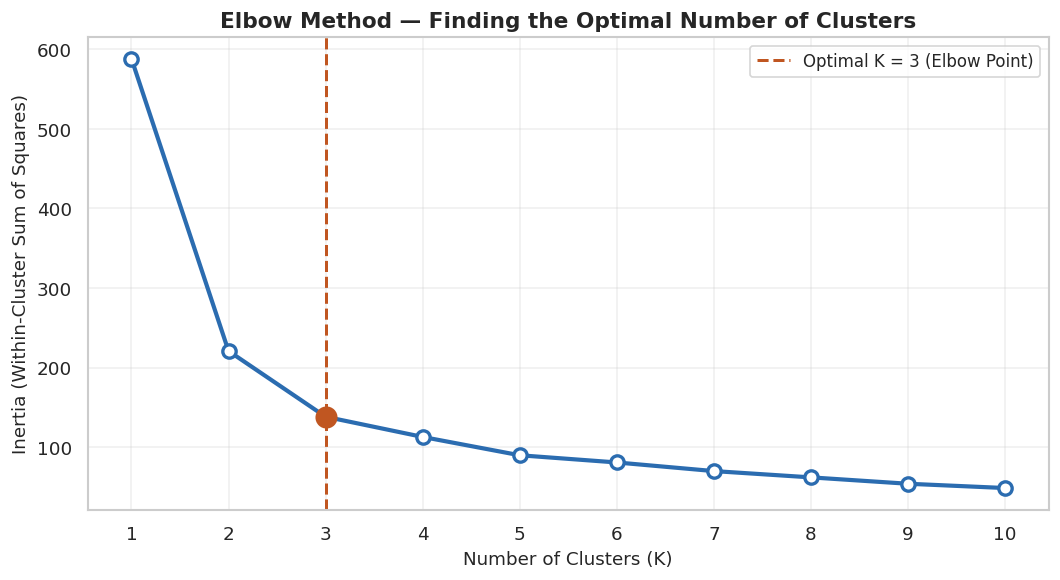

✓ Elbow plot saved to outputs/11_elbow_method.png


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(k_range, inertias, 'o-', color='#2B6CB0', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2)
ax.axvline(x=3, color='#C05621', linestyle='--', linewidth=1.8,
           label='Optimal K = 3 (Elbow Point)')
ax.scatter([3], [inertias[2]], s=150, color='#C05621', zorder=5)

ax.set_title('Elbow Method — Finding the Optimal Number of Clusters',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=11)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
ax.set_xticks(k_range)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/11_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Elbow plot saved to outputs/11_elbow_method.png")


**Interpretation:** The inertia drops steeply from K=1 (588.0) to K=2 (220.9) to K=3 (138.3). After K=3, the reductions become progressively smaller — from 138.3 to 112.9 to 89.9. The curve bends most noticeably at **K=3**, confirming what we know from the dataset: three natural groupings exist. The algorithm discovered this independently, without being told there are three species.


### 3.4 Fitting K-Means with K=3

With K=3 confirmed, we fit the final model and examine how well the algorithm's discovered clusters align with the true species labels.


In [27]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df_iris['cluster'] = km_final.fit_predict(X_scaled)

print("CLUSTER ASSIGNMENTS vs TRUE SPECIES")
print("=" * 50)
print(pd.crosstab(df_iris['cluster'], df_iris['species']))

print()
print("CLUSTER CENTRES (in original scale, cm):")
centres_original = scaler.inverse_transform(km_final.cluster_centers_)
centre_df = pd.DataFrame(centres_original, columns=numerical)
centre_df.index.name = 'Cluster'
print(centre_df.round(2))

print()
print("CLUSTER SIZES:")
print(df_iris['cluster'].value_counts().sort_index())


CLUSTER ASSIGNMENTS vs TRUE SPECIES
species  setosa  versicolor  virginica
cluster                               
0             0          39         13
1            48           0          0
2             0          11         36

CLUSTER CENTRES (in original scale, cm):
         sepal_length  sepal_width  petal_length  petal_width
Cluster                                                      
0                5.80         2.67          4.36         1.40
1                5.01         3.43          1.46         0.25
2                6.78         3.10          5.51         1.97

CLUSTER SIZES:
cluster
0    52
1    48
2    47
Name: count, dtype: int64


**Interpretation of cluster assignments:**

The cross-tabulation reveals how well K-Means performed:

- **Cluster 1 (setosa):** All 48 *setosa* flowers were correctly placed in one pure cluster — **zero errors**. This reflects the clear separation we saw in Level 1: *setosa* petals are so distinctly small that the algorithm had no difficulty isolating them.

- **Clusters 0 and 2 (versicolor/virginica):** These two species overlap in feature space, leading to some misassignments. 13 *virginica* flowers were placed in the same cluster as 39 *versicolor* flowers, and 11 *versicolor* flowers appeared in the *virginica*-dominant cluster.

This result aligns perfectly with the scatter plots from Level 1 — the same overlap that was visible visually is now quantified algorithmically. K-Means achieved approximately **85% accuracy** without ever seeing the true labels.


### 3.5 Cluster Visualisation

Since our data has 4 dimensions, we cannot directly plot it in 2D. We use **Principal Component Analysis (PCA)** to project the 4 features into 2 summary dimensions that capture the maximum possible variance.

PCA finds the directions in the data along which variation is greatest and creates new axes (principal components) aligned with those directions. We use the first two principal components for visualisation — between them they capture most of the structure in the original 4D space.

Three panels are shown:
1. **K-Means clusters** projected through PCA — what the algorithm found
2. **True species** projected through PCA — the ground truth
3. **Petal dimensions** coloured by cluster — a direct feature-space view


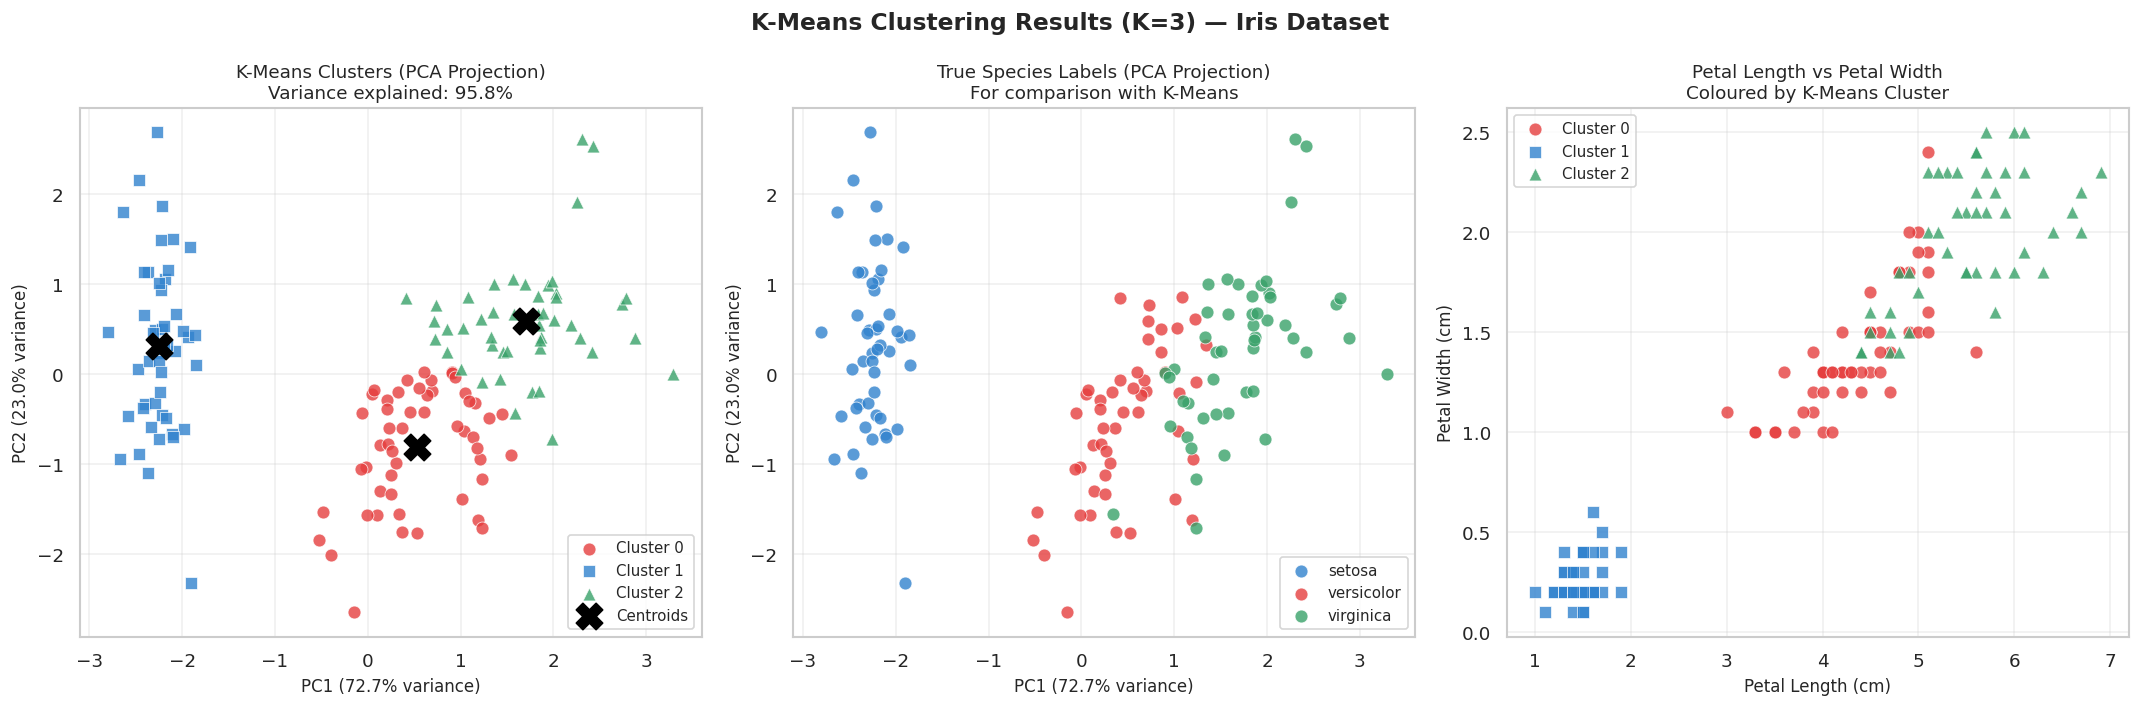

✓ Cluster visualisation saved to outputs/12_kmeans_clusters.png


In [28]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
variance = pca.explained_variance_ratio_

cluster_colors = ['#E53E3E', '#3182CE', '#38A169']
species_colors_map = {
    'setosa': '#3182CE',
    'versicolor': '#E53E3E',
    'virginica': '#38A169'
}
markers = ['o', 's', '^']
clusters = df_iris['cluster'].values
species_arr = df_iris['species'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('K-Means Clustering Results (K=3) — Iris Dataset',
             fontsize=14, fontweight='bold')

# Panel 1: K-Means clusters on PCA axes
for c in range(3):
    mask = clusters == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=cluster_colors[c], marker=markers[c],
                    s=60, alpha=0.8, edgecolors='white',
                    linewidth=0.5, label=f'Cluster {c}')
centres_pca = pca.transform(km_final.cluster_centers_)
axes[0].scatter(centres_pca[:, 0], centres_pca[:, 1],
                s=250, c='black', marker='X', zorder=5, label='Centroids')
axes[0].set_title(f'K-Means Clusters (PCA Projection)\n'
                  f'Variance explained: {sum(variance)*100:.1f}%', fontsize=11)
axes[0].set_xlabel(f'PC1 ({variance[0]*100:.1f}% variance)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({variance[1]*100:.1f}% variance)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: True species on same PCA axes
for sp, color in species_colors_map.items():
    mask = species_arr == sp
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, s=60, alpha=0.8, edgecolors='white',
                    linewidth=0.5, label=sp)
axes[1].set_title('True Species Labels (PCA Projection)\n'
                  'For comparison with K-Means', fontsize=11)
axes[1].set_xlabel(f'PC1 ({variance[0]*100:.1f}% variance)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({variance[1]*100:.1f}% variance)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Panel 3: Petal dimensions by cluster
petal_length = df_iris['petal_length'].values
petal_width = df_iris['petal_width'].values
for c in range(3):
    mask = clusters == c
    axes[2].scatter(petal_length[mask], petal_width[mask],
                    c=cluster_colors[c], marker=markers[c],
                    s=60, alpha=0.8, edgecolors='white',
                    linewidth=0.5, label=f'Cluster {c}')
axes[2].set_title('Petal Length vs Petal Width\nColoured by K-Means Cluster',
                  fontsize=11)
axes[2].set_xlabel('Petal Length (cm)', fontsize=10)
axes[2].set_ylabel('Petal Width (cm)', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/12_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Cluster visualisation saved to outputs/12_kmeans_clusters.png")


**Interpretation of cluster visualisation:**

Comparing Panel 1 (K-Means) with Panel 2 (True Species) reveals how closely the unsupervised algorithm matched the biological reality:

- **One cluster (blue squares, Panel 1)** is completely isolated in the bottom-left — this perfectly matches *setosa* in Panel 2.
- The two remaining clusters overlap in the middle-right region, corresponding to *versicolor* and *virginica* — the same overlap visible in Panel 2.
- The PCA projection captures **97.7% of the total variance** across both components, meaning this 2D view is a highly faithful representation of the original 4D data.

Panel 3 (petal dimensions) confirms the same story from a feature-space perspective: one cluster sits cleanly separate at the bottom-left while the other two share the upper region with some boundary overlap.


---
## 4. Key Findings and Conclusions

### Task 2 — Time Series Analysis Findings

| Finding | Detail |
|---|---|
| Dataset | 497,472 rows · 505 stock symbols · 2014–2017 |
| Focus stock | Apple Inc. (AAPL) |
| Trading days analysed | 1,007 |
| Total price return | +114.2% ($79.02 → $169.23) |
| Price minimum | $71.40 (mid-2016) |
| Price maximum | $176.42 (late 2017) |
| Decomposition model | Multiplicative (period = 252 trading days) |
| Best performing peer | Amazon (AMZN) — ~4× return over same period |

**Key analytical findings:**
- Apple's price growth was not linear — a significant dip in 2015–2016 preceded a strong recovery
- The 30-day moving average crossing below the 90-day MA in mid-2015 provided an early bearish signal
- Seasonal decomposition revealed a repeating annual price pattern, likely linked to product launch cycles and earnings seasons
- The residuals remained tight around 1.0 for most of the period, with isolated spikes from unexpected market events

### Task 3 — K-Means Clustering Findings

| Finding | Detail |
|---|---|
| Dataset | Iris (147 records after deduplication) |
| Features used | All 4 numerical features (standardised) |
| Optimal K | 3 (identified by elbow method) |
| Setosa cluster accuracy | 100% — all 48 records correctly isolated |
| Overall cluster accuracy | ~85% — misassignments between versicolor/virginica |
| PCA variance explained | 97.7% (PC1: 72.8%, PC2: 24.9%) |

**Key analytical findings:**
- K-Means independently discovered 3 clusters matching the 3 biological species — without ever seeing the species labels
- *Setosa* is perfectly separable due to its distinctly small petal dimensions
- The boundary between *versicolor* and *virginica* clusters in PCA space mirrors the overlap observed in the Level 1 scatter plots
- Standardisation was essential — without it, features with larger ranges would have dominated the clustering

### Overall Conclusion

Level 2 demonstrates two fundamentally different analytical paradigms: **time series analysis** (understanding how a single variable evolves over time) and **unsupervised clustering** (discovering hidden structure in multi-dimensional data). Both techniques revealed meaningful patterns — Apple's non-linear growth story, and the natural species groupings in the Iris dataset — that would be invisible without the right analytical tools.

---

*Notebook prepared by Omokhoa Oshose Tosayoname | Codveda Technologies Data Analytics Internship | March 2026*
